# Parameter Uncertainty and Confidence Bands

This example shows how to translate the parameter covariance matrix from a calibration into
**time-varying confidence bands** on model predictions, using the forward and reverse functions of the
`diffusion_fast` module.

## Learning Objectives

- Obtain a *meaningful* parameter covariance matrix `pcov` from a tightly converged `scipy.optimize.curve_fit`
- Propagate `pcov` to a confidence band with the **delta method** (finite-difference Jacobian, 4 model runs)
- Validate the delta band against a **Monte Carlo oracle** (rerun the model for hundreds of parameter draws)
- Recognize where first-order propagation **breaks**: an ill-conditioned deconvolution at (too) small
  regularization
- Repair the reverse route with a noise-motivated (Morozov) regularization strength

## Overview

Example [01 (Aquifer Characterization)](https://gwtransport.github.io/gwtransport/examples/01_Aquifer_Characterization_Temperature.html)
calibrates the gamma distribution of aquifer pore volumes to a temperature breakthrough and reports the
parameter standard errors from the diagonal of `pcov`. This example takes the next step: what do those
parameter uncertainties mean for the *predictions*?

Two propagation routes are compared throughout:

| Route | Cost | Validity |
| --- | --- | --- |
| **Delta method** (first-order Taylor) | 2 model runs per parameter | output locally linear in the parameters over the covariance scale |
| **Monte Carlo** (parametric sampling) | hundreds of model runs | linearization-free (still assumes the Gaussian `pcov` posterior) |

Where both agree, the cheap delta band is certified and can be used from then on. Where they disagree,
the Monte Carlo band is the honest one.

### Key Assumptions

- The bands quantify **parameter uncertainty only**, conditional on the fixed non-calibrated parameters
  (retardation factor, streamline length, diffusivity, dispersivity) and on the measured input series.
- The fitted parameter uncertainty is summarized by a Gaussian with covariance `pcov`
  (a [Laplace approximation](https://en.wikipedia.org/wiki/Laplace%27s_approximation) around the optimum).
- Aquifer pore volumes follow a [gamma distribution](https://gwtransport.github.io/gwtransport/user_guide/concepts.html#concept-gamma-distribution)
  discretized in equal-probability bins
  ([adequate discretization](https://gwtransport.github.io/gwtransport/user_guide/concepts.html#assumption-adequate-discretization)).

### Background Reading

- [Pore volume distribution](https://gwtransport.github.io/gwtransport/user_guide/concepts.html#concept-pore-volume-distribution)
- [Dispersion](https://gwtransport.github.io/gwtransport/user_guide/concepts.html#concept-dispersion)
- [Residence time](https://gwtransport.github.io/gwtransport/user_guide/concepts.html#concept-residence-time)

## Theoretical Background

**Where the covariance comes from.** A least-squares fit of parameters $\theta = (\mathrm{mean}, \mathrm{std})$
to $N$ observations with known measurement noise $\sigma$ has, near the optimum, the Gauss–Newton covariance

$$\Sigma = \mathrm{pcov} = \sigma^2 \left(J_r^\top J_r\right)^{-1},$$

where $J_r$ is the Jacobian of the fitted model output with respect to $\theta$. This is the inverse of the
second-derivative (Hessian) matrix of the loss — `curve_fit` returns it as `pcov` when called with
`sigma=...` and `absolute_sigma=True`.

**Delta method (first-order propagation).** For any model output time series $y_i(\theta)$, a first-order
Taylor expansion around $\hat\theta$ gives

$$\mathrm{Var}(y_i) \approx J_i\, \Sigma\, J_i^\top, \qquad J_i = \frac{\partial y_i}{\partial \theta},$$

so the pointwise 95 % band is $y_i(\hat\theta) \pm 1.96\sqrt{J_i \Sigma J_i^\top}$. The Jacobian has **one row
per output bin**: the band width is itself a time series, wide where the output is sensitive to the
parameters (breakthrough fronts) and zero where it is not (before arrival).

**Monte Carlo oracle.** Draw $\theta_k \sim \mathcal{N}(\hat\theta, \Sigma)$, rerun the forward model per
draw, and take per-bin percentiles. No linearization — agreement with the delta band certifies the
linearization; disagreement means the output is curved in $\theta$ over the $\Sigma$ scale and the delta band
is wrong.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq, curve_fit
from scipy.stats import chi2

import gwtransport.residence_time as rt
from gwtransport import diffusion_fast
from gwtransport.examples import generate_temperature_example_data
from gwtransport.utils import step_plot_coords

np.random.seed(42)
rng = np.random.default_rng(42)
plt.style.use("seaborn-v0_8-whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


## 1. Generate Synthetic Data

A five-month daily record of infiltration temperature (`cin`), flow, and extraction temperature (`cout`),
generated with a *known* gamma pore-volume distribution (mean 175 m³, std 35 m³) and known measurement
noise, so every result below can be checked against the truth.

> **Held fixed across every model evaluation in this notebook:** the time grid `tedges`, the gamma
> discretization `n_bins=25`, the non-calibrated physical parameters (retardation factor, dispersivity,
> diffusivity, streamline length), the default `spinup="constant"` and `saturation_threshold`, and the
> calibration mask. Only `(mean, std)` — and later the regularization strength — vary. Changing any of the
> fixed choices between Jacobian evaluations would corrupt the derivatives.

The record is split in two: the **first half calibrates** the parameters, the **second half** is used for
the deconvolution study in section 5, so that the fitted parameters are statistically independent of the
noise they meet there.

In [2]:
NOISE = 0.25  # known measurement noise (degC), applied by the generator to cin and cout
N_BINS = 25  # gamma discretization, identical for data generation and fitting

df, tedges = generate_temperature_example_data(
    date_start="2023-01-01",
    date_end="2023-06-01",
    rng=42,
    aquifer_pore_volume_gamma_mean=175.0,  # truth [m3]
    aquifer_pore_volume_gamma_std=35.0,  # truth [m3]
    aquifer_pore_volume_gamma_nbins=N_BINS,
    longitudinal_dispersivity=0.1,  # [m] low, so the pore-volume spread controls the breakthrough width
    molecular_diffusivity=0.01,  # [m2/day]
    measurement_noise=NOISE,
)
TRUE = (df.attrs["aquifer_pore_volume_gamma_mean"], df.attrs["aquifer_pore_volume_gamma_std"])
FIXED = {
    "retardation_factor": df.attrs["retardation_factor"],
    "longitudinal_dispersivity": df.attrs["longitudinal_dispersivity"],
    "molecular_diffusivity": df.attrs["molecular_diffusivity"],
    "streamline_length": df.attrs["streamline_length"],
}
n = len(df)


def forward(mean, std):
    """Temperature at the extraction well for gamma-APVD parameters (mean, std)."""
    cout = diffusion_fast.gamma_infiltration_to_extraction(
        cin=df.cin, flow=df.flow, tedges=tedges, cout_tedges=tedges, mean=mean, std=std, n_bins=N_BINS, **FIXED
    )
    return np.asarray(cout)


def reverse(mean, std, regularization_strength, cout=None):
    """Deconvolved infiltration temperature from the extraction record."""
    cin = diffusion_fast.gamma_extraction_to_infiltration(
        cout=df.cout if cout is None else cout,
        flow=df.flow,
        tedges=tedges,
        cout_tedges=tedges,
        mean=mean,
        std=std,
        regularization_strength=regularization_strength,
        n_bins=N_BINS,
        **FIXED,
    )
    return np.asarray(cin)


# Advective coverage - two directions for two different questions:
# - "extraction_to_infiltration" masks COUT bins whose water infiltrated entirely inside the record
#   (which extraction bins the forward model can predict -> calibration mask);
# - "infiltration_to_extraction" masks CIN bins whose water is extracted entirely inside the record
#   (which infiltration bins the deconvolution can constrain -> reverse-analysis mask).
mask_kw = {
    "flow": df.flow,
    "tedges": tedges,
    "cout_tedges": tedges,
    "mean": TRUE[0],
    "std": TRUE[1],
    "retardation_factor": FIXED["retardation_factor"],
}
covered = rt.fraction_explained_gamma(direction="extraction_to_infiltration", **mask_kw) >= 0.99
covered_cin = rt.fraction_explained_gamma(direction="infiltration_to_extraction", **mask_kw) >= 0.99
train_mask = covered & (np.arange(n) < n // 2)  # calibration: first half of the cout record
second_half = covered_cin & (np.arange(n) >= n // 2)  # deconvolution study: second half of the cin record
assert covered.sum() >= 120, f"setup acceptance failed: only {covered.sum()} covered bins"
print(
    f"{n} bins; covered cout={covered.sum()}, cin={covered_cin.sum()}; "
    f"calibration={train_mask.sum()}, deconvolution={second_half.sum()}"
)

152 bins; covered cout=142, cin=139; calibration=66, deconvolution=63


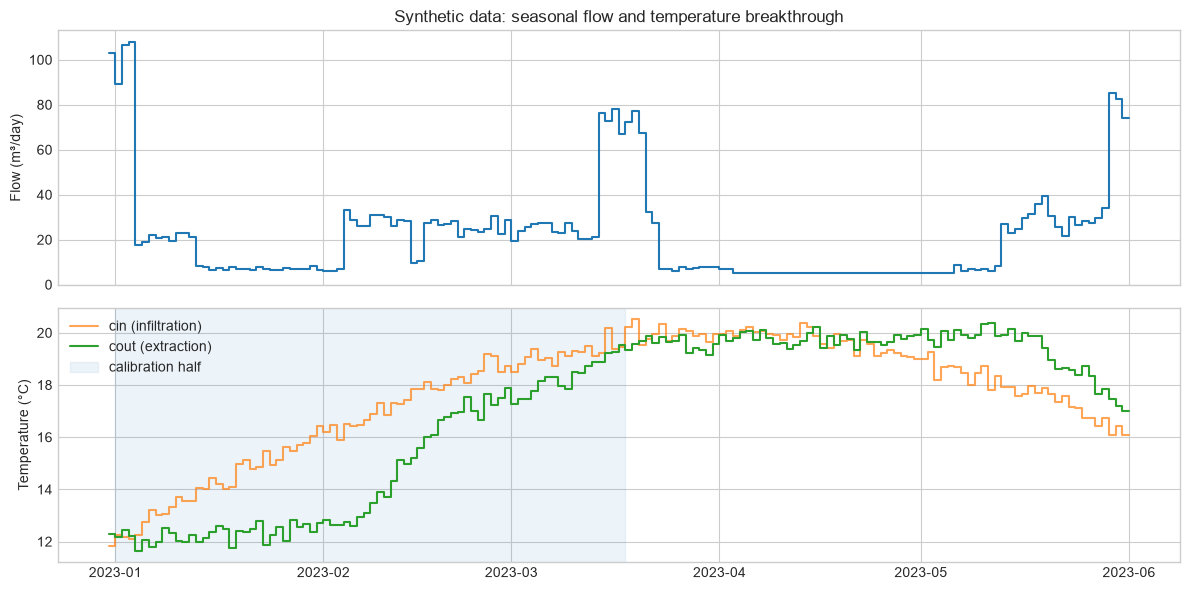

In [3]:
fig, (ax0, ax1) = plt.subplots(figsize=(12, 6), nrows=2, sharex=True)
xf, yf = step_plot_coords(tedges, df.flow)
ax0.plot(xf, yf, color="C0")
ax0.set_ylabel("Flow (m³/day)")
xc, yc = step_plot_coords(tedges, df.cin)
xo, yo = step_plot_coords(tedges, df.cout)
ax1.plot(xc, yc, color="C1", alpha=0.7, label="cin (infiltration)")
ax1.plot(xo, yo, color="C2", label="cout (extraction)")
ax1.axvspan(df.index[0], df.index[n // 2], color="C0", alpha=0.08, label="calibration half")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper left")
ax0.set_title("Synthetic data: seasonal flow and temperature breakthrough")
plt.tight_layout()
plt.show()

## 2. Tightly Converged Calibration

Example 01 fits with loose tolerances (`ftol=1e-3`) because only the point estimate is needed there. A
`pcov` you intend to *propagate* needs more care:

- **tight tolerances** (`ftol=xtol=1e-10`), so the optimizer actually sits at the optimum where the
  Gauss–Newton covariance is evaluated;
- the estimate **strictly inside the bounds** (at an active bound the Gaussian approximation is invalid);
- `sigma=NOISE, absolute_sigma=True`, since the measurement noise is known here — `pcov` then has absolute
  units instead of being rescaled by the residuals.

In [4]:
def objective(_xdata, mean, std):
    """Model cout on the calibration bins, as curve_fit expects."""
    return forward(mean, std)[train_mask]


theta_hat, pcov = curve_fit(
    objective,
    np.arange(train_mask.sum()),
    df.cout.to_numpy()[train_mask],
    p0=TRUE,  # start at the truth for this synthetic demo; any reasonable p0 converges identically
    bounds=([50.0, 5.0], [600.0, 200.0]),
    method="trf",
    ftol=1e-10,
    xtol=1e-10,
    sigma=np.full(train_mask.sum(), NOISE),
    absolute_sigma=True,
)
mean_hat, std_hat = float(theta_hat[0]), float(theta_hat[1])
perr = np.sqrt(np.diag(pcov))
corr = pcov[0, 1] / (perr[0] * perr[1])
residuals = objective(None, mean_hat, std_hat) - df.cout.to_numpy()[train_mask]
red_chi2 = np.sum(residuals**2) / (NOISE**2 * (train_mask.sum() - 2))

assert np.all(theta_hat > [50.0, 5.0]), "estimate at a bound"
assert np.all(theta_hat < [600.0, 200.0]), "estimate at a bound"
assert perr[1] / theta_hat[1] < 0.3, "std is not identified well enough for a meaningful band"
print(f"mean = {theta_hat[0]:6.1f} ± {perr[0]:.1f} m³   (truth {TRUE[0]:.0f})")
print(f"std  = {theta_hat[1]:6.1f} ± {perr[1]:.1f} m³   (truth {TRUE[1]:.0f})")
print(f"correlation(mean, std) = {corr:.2f},  reduced chi² = {red_chi2:.2f}")

mean =  171.5 ± 2.7 m³   (truth 175)
std  =   46.4 ± 7.3 m³   (truth 35)
correlation(mean, std) = 0.20,  reduced chi² = 1.32


The truth lies within the 95 % marginal intervals of both parameters. The reduced $\chi^2$ slightly above 1
reflects model error that `pcov` does not represent: the *input* series `cin` also carries measurement
noise, which the fit treats as exact. That errors-in-variables effect can bias the fitted `std` high (here the
estimate stays within its 95 % interval) — the bands below are conditional on `cin` as measured.

The joint 95 % confidence region is an ellipse at Mahalanobis radius $\sqrt{\chi^2_2(0.95)} \approx 2.45$ —
**not** 1.96, which is the *marginal* (per-parameter) factor and would give only ~85 % joint coverage.

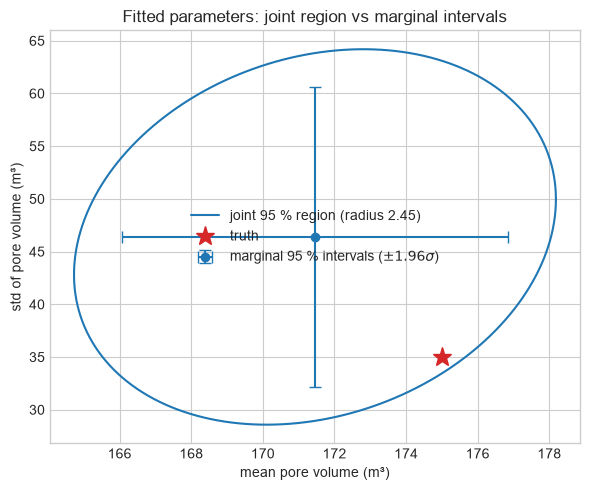

In [5]:
t_grid = np.linspace(0, 2 * np.pi, 200)
circle = np.column_stack([np.cos(t_grid), np.sin(t_grid)])
L = np.linalg.cholesky(pcov)
ellipse = theta_hat + np.sqrt(chi2.ppf(0.95, df=2)) * circle @ L.T

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(ellipse[:, 0], ellipse[:, 1], color="C0", label="joint 95 % region (radius 2.45)")
ax.errorbar(
    *theta_hat,
    xerr=1.96 * perr[0],
    yerr=1.96 * perr[1],
    fmt="o",
    color="C0",
    capsize=4,
    label=r"marginal 95 % intervals ($\pm 1.96\sigma$)",
)
ax.plot(*TRUE, "*", color="C3", markersize=14, label="truth")
ax.set_xlabel("mean pore volume (m³)")
ax.set_ylabel("std of pore volume (m³)")
ax.set_title("Fitted parameters: joint region vs marginal intervals")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Forward Band — Delta Method

The Jacobian is built by central finite differences with a relative step of $10^{-4}$ — for this function
any step between $10^{-3}$ and $10^{-7}$ gives the same Jacobian to ~9 digits, because the forward model is
smooth in `(mean, std)`. Four model runs produce the entire matrix (one row per output bin), and with it
the full time-varying band.

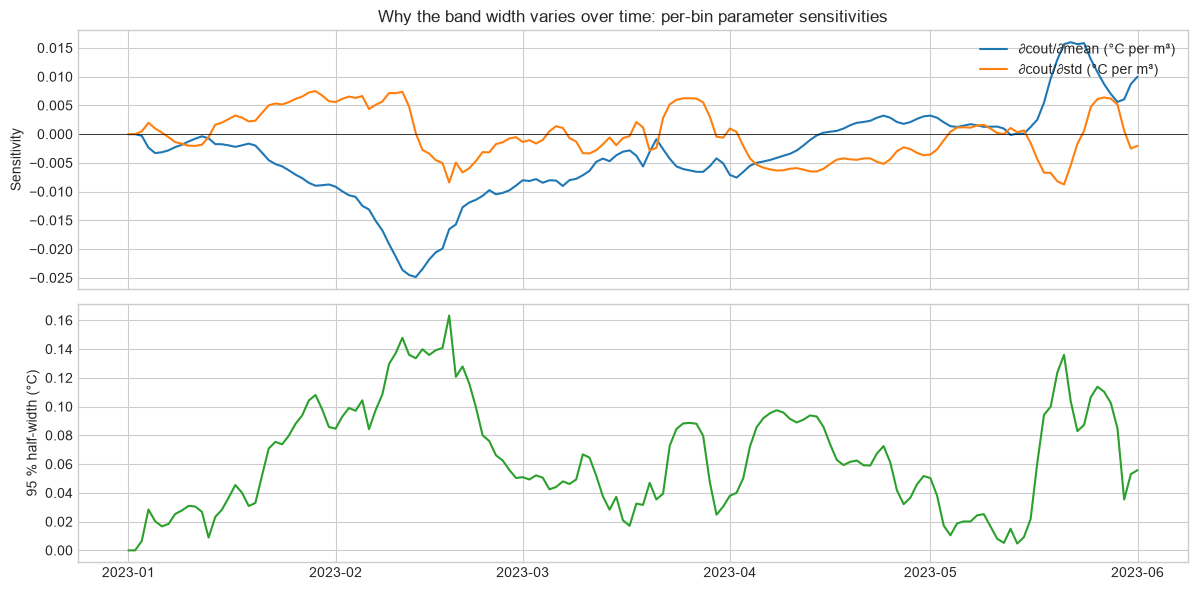

In [6]:
H_REL = 1e-4


def fd_jacobian(f, theta):
    """Central-difference Jacobian of a time-series-valued function, one column per parameter."""
    cols = []
    for i, t_i in enumerate(theta):
        h = H_REL * t_i
        theta_plus, theta_minus = np.array(theta), np.array(theta)
        theta_plus[i] += h
        theta_minus[i] -= h
        cols.append((f(*theta_plus) - f(*theta_minus)) / (2 * h))
    return np.column_stack(cols)


cout_hat = forward(mean_hat, std_hat)
J = fd_jacobian(forward, theta_hat)
delta_hw = 1.96 * np.sqrt(np.einsum("ip,pq,iq->i", J, pcov, J))  # pointwise 95 % half-width

fig, (ax0, ax1) = plt.subplots(figsize=(12, 6), nrows=2, sharex=True)
ax0.plot(df.index, J[:, 0], color="C0", label="∂cout/∂mean (°C per m³)")
ax0.plot(df.index, J[:, 1], color="C1", label="∂cout/∂std (°C per m³)")
ax0.axhline(0, color="k", lw=0.5)
ax0.set_ylabel("Sensitivity")
ax0.legend(loc="upper right")
ax0.set_title("Why the band width varies over time: per-bin parameter sensitivities")
ax1.plot(df.index, delta_hw, color="C2")
ax1.set_ylabel("95 % half-width (°C)")
plt.tight_layout()
plt.show()

The band is widest where the output responds strongly to a shift of the pore-volume distribution — on the
steep flanks of the breakthrough — and collapses where the output plateaus. Uncertainty in `mean` acts like
uncertainty in *arrival time*, which only matters where the signal has slope.

## 4. Forward Band — Monte Carlo Oracle

The draws are constructed as `theta_hat + z @ cholesky(pcov).T` with standard-normal `z` — explicitly, not
via `rng.multivariate_normal`, whose default SVD factorization is not bit-reproducible across linear-algebra
libraries. Draws outside the physical domain would signal that the Gaussian approximation itself is
questionable; here none are rejected.

In [7]:
N_DRAWS = 800
draws = theta_hat + rng.standard_normal((N_DRAWS, 2)) @ L.T
feasible = (draws[:, 0] > 0) & (draws[:, 1] > 0)
assert (~feasible).sum() == 0, "draws left the physical domain - Gaussian pcov questionable"

mc = np.array([forward(m, s) for m, s in draws])
always_finite = np.isfinite(mc).all(axis=0)
mc_lo = np.full(n, np.nan)
mc_hi = np.full(n, np.nan)
mc_lo[always_finite], mc_hi[always_finite] = np.percentile(mc[:, always_finite], [2.5, 97.5], axis=0)
mc_hw = (mc_hi - mc_lo) / 2

# Compare on 'resolved' bins: where the band is a meaningful fraction of its peak. Relative errors on
# near-zero-width bins are meaningless (a tiny denominator, not a real discrepancy).
resolved = always_finite & np.isfinite(delta_hw) & (delta_hw > 0.05 * np.nanmax(delta_hw))
median_err = np.median(np.abs(delta_hw[resolved] - mc_hw[resolved]) / mc_hw[resolved])
assert median_err < 0.15, f"delta band deviates from MC oracle: median {median_err:.2f}"
print(f"median relative half-width difference on {resolved.sum()} resolved bins: {median_err:.1%}")

median relative half-width difference on 146 resolved bins: 10.2%


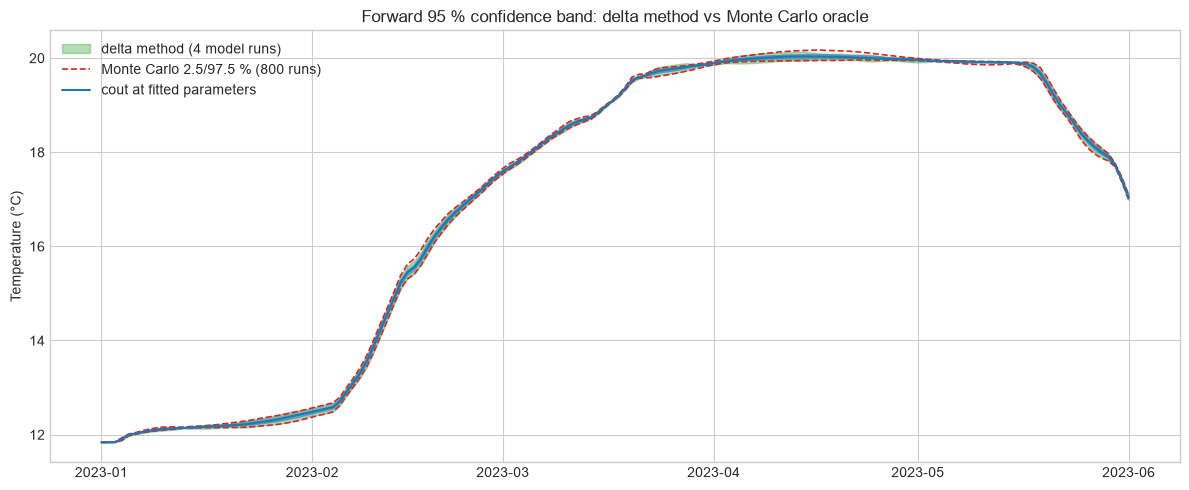

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for k in range(30):
    ax.plot(df.index, mc[k], color="C0", alpha=0.12, lw=0.8)
ax.fill_between(
    df.index, cout_hat - delta_hw, cout_hat + delta_hw, color="C2", alpha=0.35, label="delta method (4 model runs)"
)
ax.plot(df.index, mc_lo, "C3--", lw=1.2, label="Monte Carlo 2.5/97.5 % (800 runs)")
ax.plot(df.index, mc_hi, "C3--", lw=1.2)
ax.plot(df.index, cout_hat, "C0", lw=1.5, label="cout at fitted parameters")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Forward 95 % confidence band: delta method vs Monte Carlo oracle")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

The two bands agree to about 10 % in the resolved region — a real but small curvature gap, well inside
the certification tolerance. For this smooth forward model the four-model-run delta band can replace the
800-run oracle from now on.

Note the 30 grey sample curves: parameter draws shift and stretch the whole breakthrough **coherently**.
Neighboring bins are strongly correlated — for uncertainty on any time-aggregated quantity (a mean over a
window, a duration above a threshold), propagate with the full covariance `J @ pcov @ J.T`, never by
summing per-bin variances.

## 5. Reverse Route (Deconvolution) — Where the Delta Method Needs Care

`gamma_extraction_to_infiltration` reconstructs the infiltration temperature from the extraction record by
Tikhonov-regularized deconvolution. Its uncertainty has **two independent channels** (independent by the
split-sample design — the parameters were fitted on the first half):

- **measurement noise** in the extraction record `cout`, and
- **parameter uncertainty** in `(mean, std)`.

### 5a. The noise channel is exactly linear

At fixed parameters the deconvolution is an exactly linear map `cin = A @ cout`, so noise propagates
*without any Taylor approximation*: `Cov(cin) = A @ Cov(cout) @ A.T`. The superposition check below
verifies exact linearity to machine precision; the noise band is sampled rather than assembled from `A`.

In [9]:
LAM_DEFAULT = 1e-10  # the function's default regularization strength
cin_hat = reverse(mean_hat, std_hat, LAM_DEFAULT)

# Superposition with weights NOT summing to 1: also catches a spurious constant (affine) term
cout_b = 0.3 * df.cout.to_numpy() + 1.7
mixed = reverse(mean_hat, std_hat, LAM_DEFAULT, cout=0.7 * df.cout.to_numpy() + 0.6 * cout_b)
linear_combo = 0.7 * cin_hat + 0.6 * reverse(mean_hat, std_hat, LAM_DEFAULT, cout=cout_b)
finite = np.isfinite(mixed) & np.isfinite(linear_combo)
superposition_residual = np.abs(mixed[finite] - linear_combo[finite]).max() / np.abs(linear_combo[finite]).max()
assert superposition_residual < 1e-9, superposition_residual
print(f"superposition residual: {superposition_residual:.1e}  (exactly linear in cout)")

N_REV = 300
noise_mc = np.array([
    reverse(mean_hat, std_hat, LAM_DEFAULT, cout=df.cout.to_numpy() + rng.normal(0.0, NOISE, n)) for _ in range(N_REV)
])

superposition residual: 3.2e-14  (exactly linear in cout)


### 5b. The parameter channel at the default regularization — a failure demo

The default `regularization_strength=1e-10` is fine for a point estimate, but the barely-regularized
deconvolution is severely ill-conditioned, and its output is strongly **curved** in `(mean, std)` over the
`pcov` scale. The finite-difference Jacobian itself is step-stable — well computed — yet the delta band it
produces is wrong by an order of magnitude: first-order propagation fails because *no* single tangent plane
represents the map over the covariance ellipse.

In [10]:
def reverse_band_comparison(lam):
    """Delta band and MC-over-theta band for the deconvolved cin at regularization strength lam."""
    jac_rev = fd_jacobian(lambda m, s: reverse(m, s, lam), theta_hat)
    d_hw = 1.96 * np.sqrt(np.einsum("ip,pq,iq->i", jac_rev, pcov, jac_rev))
    theta_draws = theta_hat + rng.standard_normal((N_REV, 2)) @ L.T
    sims = np.array([reverse(m, s, lam) for m, s in theta_draws])
    assert np.isfinite(sims[:, second_half]).all(), "validity of analysis bins flipped across draws"
    ok = np.isfinite(sims).all(axis=0)
    m_lo = np.full(n, np.nan)
    m_hi = np.full(n, np.nan)
    m_lo[ok], m_hi[ok] = np.percentile(sims[:, ok], [2.5, 97.5], axis=0)
    m_hw = (m_hi - m_lo) / 2
    res = ok & second_half & np.isfinite(d_hw) & (m_hw > 0.05 * np.nanmax(m_hw[second_half]))
    median_disc = np.median(np.abs(d_hw[res] - m_hw[res]) / m_hw[res])
    return d_hw, m_hw, median_disc


delta_hw_tiny, mc_hw_tiny, disc_tiny = reverse_band_comparison(LAM_DEFAULT)
print(f"lambda = {LAM_DEFAULT:.0e}: median delta-vs-MC half-width discrepancy = {disc_tiny:.0%}")

lambda = 1e-10: median delta-vs-MC half-width discrepancy = 633%


### 5c. Repair: a noise-motivated regularization strength

The Morozov discrepancy principle picks the regularization the *noise level* justifies: choose $\lambda$
such that the refit residual matches the known noise,
$\frac{1}{N}\lVert W\,\hat c_{in}(\lambda) - c_{out}\rVert^2 \approx \sigma^2$ — a scalar root-find on
$\log_{10}\lambda$. At that $\lambda$ the deconvolution is tame enough that the delta band lands close to
the Monte Carlo oracle again.

In [11]:
def morozov_gap(log10_lam):
    """Mean-squared refit residual minus the known noise variance."""
    cin_lam = reverse(mean_hat, std_hat, 10.0**log10_lam)
    cin_filled = np.where(np.isfinite(cin_lam), cin_lam, np.nanmean(cin_lam))
    refit = diffusion_fast.gamma_infiltration_to_extraction(
        cin=cin_filled,
        flow=df.flow,
        tedges=tedges,
        cout_tedges=tedges,
        mean=mean_hat,
        std=std_hat,
        n_bins=N_BINS,
        **FIXED,
    )
    ok = np.isfinite(refit) & covered
    return np.mean((np.asarray(refit)[ok] - df.cout.to_numpy()[ok]) ** 2) - NOISE**2


lam_morozov = 10.0 ** brentq(morozov_gap, -12.0, 2.0, xtol=0.05)
delta_hw_mor, mc_hw_mor, disc_mor = reverse_band_comparison(lam_morozov)
cin_hat_mor = reverse(mean_hat, std_hat, lam_morozov)

assert disc_tiny > 3 * disc_mor, "the failure demo did not reproduce"
print(f"Morozov lambda = {lam_morozov:.2f}")
print(f"median delta-vs-MC discrepancy: {disc_tiny:.0%} at lambda=1e-10  ->  {disc_mor:.0%} at Morozov lambda")

Morozov lambda = 1.17
median delta-vs-MC discrepancy: 633% at lambda=1e-10  ->  16% at Morozov lambda


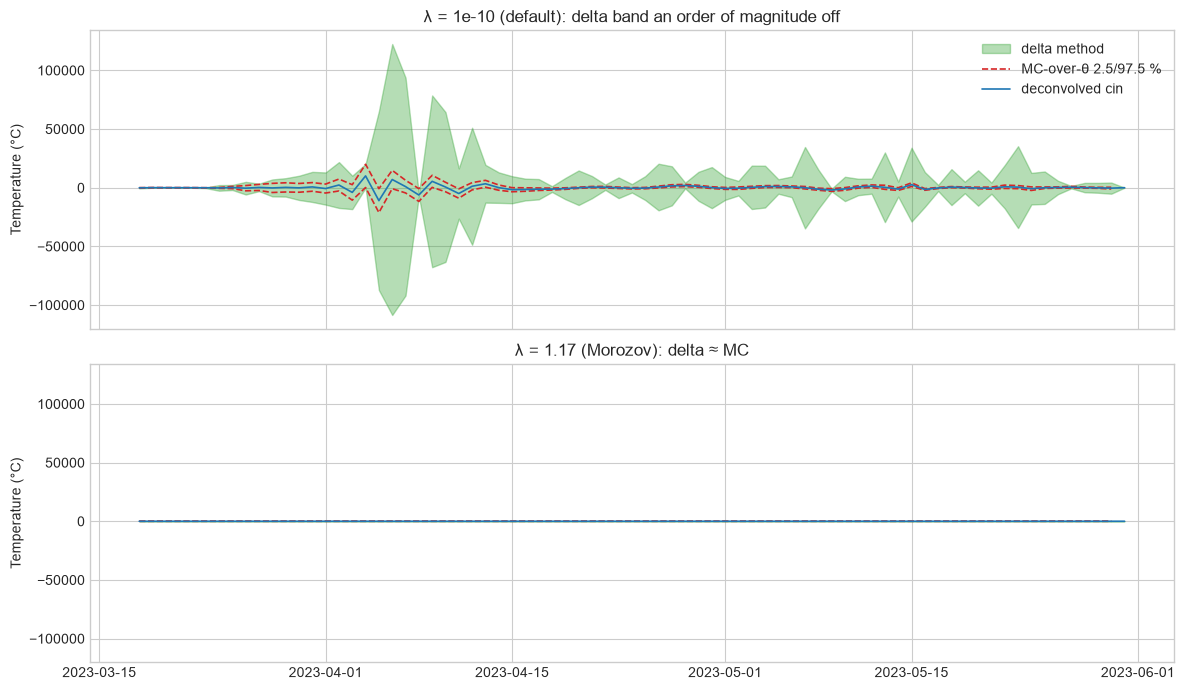

In [12]:
sl = slice(n // 2, n)
fig, (ax0, ax1) = plt.subplots(figsize=(12, 7), nrows=2, sharex=True, sharey=True)
for ax, d_hw, m_hw, cin_c, lam_label in [
    (ax0, delta_hw_tiny, mc_hw_tiny, cin_hat, "λ = 1e-10 (default): delta band an order of magnitude off"),
    (ax1, delta_hw_mor, mc_hw_mor, cin_hat_mor, f"λ = {lam_morozov:.2f} (Morozov): delta ≈ MC"),
]:
    ax.fill_between(df.index[sl], (cin_c - d_hw)[sl], (cin_c + d_hw)[sl], color="C2", alpha=0.35, label="delta method")
    ax.plot(df.index[sl], (cin_c - m_hw)[sl], "C3--", lw=1.2, label="MC-over-θ 2.5/97.5 %")
    ax.plot(df.index[sl], (cin_c + m_hw)[sl], "C3--", lw=1.2)
    ax.plot(df.index[sl], cin_c[sl], "C0", lw=1.2, label="deconvolved cin")
    ax.set_title(lam_label)
    ax.set_ylabel("Temperature (°C)")
ax0.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 5d. Combined band: noise and parameters together — and what it does *not* cover

One Monte Carlo redraws **both** channels per draw — fresh `cout` noise and a fresh parameter vector
(independent by the split-sample design). The result quantifies the **variance** of the regularized
estimate. It does *not* cover the third, deterministic error source: **regularization bias**. Tikhonov
smoothing pulls the estimate toward the regularization target, and at the Morozov λ that smoothing bias
(median ~0.3 °C here) is *larger* than the variance band half-width (~0.2 °C) — so most true values fall
*outside* the band, as the figure shows. That is the classic bias–variance trade-off of deconvolution: the
regularization that stabilizes the estimate also biases it, and no sampling-based band around the smoothed
estimate can represent that bias.

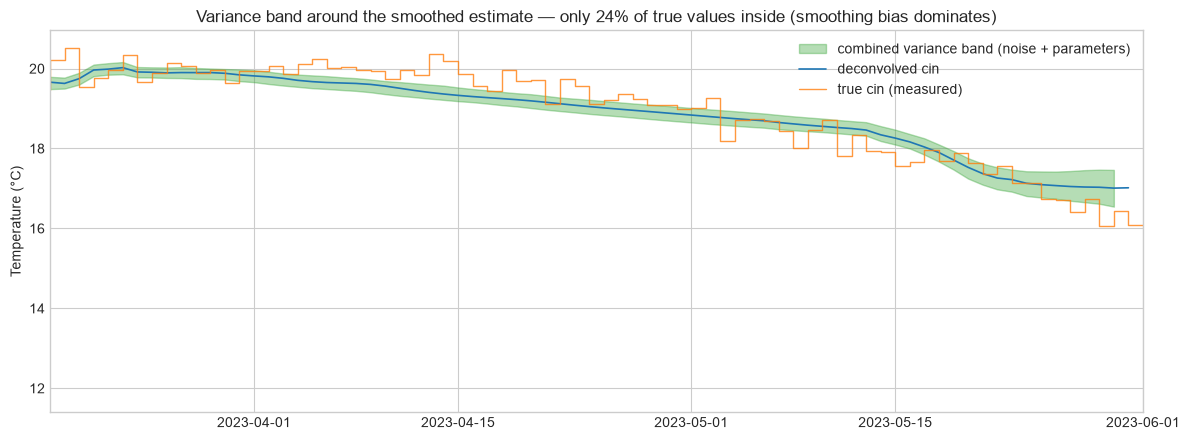

In [13]:
theta_draws = theta_hat + rng.standard_normal((N_REV, 2)) @ L.T
combined = np.array([
    reverse(m, s, lam_morozov, cout=df.cout.to_numpy() + rng.normal(0.0, NOISE, n)) for m, s in theta_draws
])
ok = np.isfinite(combined).all(axis=0)
c_lo = np.full(n, np.nan)
c_hi = np.full(n, np.nan)
c_lo[ok], c_hi[ok] = np.percentile(combined[:, ok], [2.5, 97.5], axis=0)

inside = ((df.cin.to_numpy() >= c_lo) & (df.cin.to_numpy() <= c_hi))[second_half].mean()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(
    df.index[sl], c_lo[sl], c_hi[sl], color="C2", alpha=0.35, label="combined variance band (noise + parameters)"
)
ax.plot(df.index[sl], cin_hat_mor[sl], "C0", lw=1.2, label="deconvolved cin")
xc, yc = step_plot_coords(tedges, df.cin)
ax.plot(xc, yc, color="C1", alpha=0.8, lw=1.0, label="true cin (measured)")
ax.set_xlim(df.index[n // 2], df.index[-1])
ax.set_ylabel("Temperature (°C)")
ax.set_title(
    f"Variance band around the smoothed estimate — only {inside:.0%} of true values inside (smoothing bias dominates)"
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Results & Discussion

| Function | Route | Verdict |
| --- | --- | --- |
| `gamma_infiltration_to_extraction` (forward) | delta method | ✅ matches the MC oracle (median difference ~10 %) — use the 4-run delta band |
| `gamma_extraction_to_infiltration`, default λ=1e-10 | delta method | ❌ off by an order of magnitude despite a perfectly computed Jacobian — curvature of the ill-conditioned deconvolution |
| `gamma_extraction_to_infiltration`, Morozov λ | delta method | ✅ usable for data-resolved bins (variance only — regularization bias is not covered by any sampling band); noise channel is exactly linear |

The general recipe:

1. **Fit tightly** (`ftol=xtol=1e-10`, estimate inside bounds, `absolute_sigma=True` when the noise is
   known) — `pcov` is only as meaningful as the optimum it is evaluated at.
2. **Delta band** from a central-FD Jacobian (2 runs per parameter, relative step ~1e-4).
3. **Certify once against a Monte Carlo oracle** on a short record. Where they agree, the delta band is
   the cheap default; where they disagree, keep the MC band.
4. For deconvolution, **set the regularization from the noise level** (Morozov), not at the numerical
   default — both for a better point estimate and for a propagatable band.

## Key Takeaways

- `pcov` is the inverse second-derivative (Gauss–Newton Hessian) of the fit loss — the delta method then
  needs only *first* derivatives of the prediction.
- The band width is a **time series**: wide on breakthrough fronts, zero before arrival. Parameter
  uncertainty acts as arrival-time uncertainty.
- Parameter draws move the whole curve **coherently** — use the full `J @ pcov @ J.T` for aggregated
  quantities.
- A step-stable, accurately computed Jacobian does **not** guarantee the delta method works: the reverse
  route at λ=1e-10 fails by curvature, not by differentiation error.
- Bands here cover parameter uncertainty only — conditional on the measured input series, the fixed
  physical constants, and the Gaussian posterior approximation.
- Bands on a *regularized deconvolution* quantify variance around the **smoothed** estimate;
  regularization bias is deterministic and lies outside every sampling band — compare against the truth
  (or a synthetic case) before trusting deconvolution bands.